RNN - Erro dos pesos computados e usado somente durante a iteração

In [1]:
import numpy as np
from numpy import linalg as LA
import pandas as pd
import operator as op
import ipynbname
import math
import matplotlib.cm as cm
import optuna
from optuna.exceptions import TrialPruned
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib as mpl
#from Testing.RTLO import *
from Functions.RLS import *
from Functions.Graphs import *
from sklearn.metrics import root_mean_squared_error as rmse
FileName = ipynbname.name()

params =  [13, 20, 8, 1e-06, 0.001, 1e-07, 0.0001, 1, 0.99, 10000.0]

df = pd.read_csv(r'Dataset\Bearing1_1.csv')
sig = df['PC1'].values

def prepare_data(sig, n, m):
    X, Y = [], []
    # O shift (s) é calculado para alinhar o final de Y com a predição futura
    # Seguindo sua lógica: se n=4, m=3 -> Y começa no índice 2 (hi_3)
    s = n - m + 1 
    
    for i in range(len(sig) - n - 1):
        X.append(sig[i : i + n])
        Y.append(sig[i + s : i + s + m])
        
    return np.array(X), np.array(Y)


In [78]:
def f(x):
    return np.tanh(x)
def d_f(x):
    return 1/np.cosh(10*np.tanh(x/10))**2  # the tanh prevents oveflow
def split_matrix(A):
    Ap = np.where(A > 0, A, 0)
    An = np.where(A < 0, A, 0)
    return An, Ap

def get_interval(A):
    v_max = np.max(A, axis=0)
    v_min = np.min(A, axis=0)
    
    return v_min, v_max

class RTLO:
    def __init__(self, nIN, nHS, nOUT,ηS=[0.1,0.1,0.1], τ=10,lr=1e-5):
        np.random.seed(42)
        self.nIN = nIN
        self.nHS = nHS
        self.nOUT = nOUT
        self.ΔOUT = np.zeros((nOUT, nHS))
        self.ΔHS = np.zeros((nHS, nHS))
        self.ΔIN = np.zeros((nHS, nIN))
        self.xI = np.zeros(nIN)
        self.ηS = np.array(ηS)
        self.τ = τ
        self.ε = 0.1
        self.h0 = 0
        self.h = np.zeros(nHS)
        self.hU = np.zeros(nHS)
        self.hL = np.zeros(nHS)
        self.hI = np.zeros(nHS)
        self.hF = np.zeros(nHS)
        self.ht = np.zeros(nHS)
        self.htI = np.zeros((nHS,2))
        self.htL = np.zeros(nHS)
        self.htU = np.zeros(nHS)
        self.htUF = np.zeros(nHS)
        self.htUF = np.zeros(nHS)
        self.k = 0
        self.u = None
        self.decay = lr
        self.wIN = 0.1*(np.random.rand(nHS, nIN) - 1)
        self.wHS = 1.5*np.random.randn(nHS, nHS)/nHS**0.5
        self.wOUT = 0.1*(2*np.random.rand(nOUT, nHS) - 1)/nHS**0.5
        self.b = np.random.randn(nHS, nOUT)/nOUT**0.5
        self.p = np.zeros((self.nHS, self.nHS))
        self.q = np.zeros((self.nHS, self.nIN))
        self.wIN = self.xavier_uniform([nHS, nIN])
        self.wHS = self.xavier_uniform([nHS, nHS])
        self.wOUT = self.xavier_uniform([nOUT, nHS])
        self.b = np.random.randn(nHS, nOUT)/nOUT**0.5
        self.rls = RLS_LogarithmicRegressor(0.9,10000)
        self.yP = np.array([])
        self.yR = np.array([])
        self.yL = np.array([])
        self.yU = np.array([])
        self.eP = np.array([])
        self.eR = np.array([])
        self.eRMSE = np.array([])


    def fit_V2(self, x, y, tip=1, store = False):
        #print('self.hI:',self.hI[:5])
        
        self.ηS = self.ηS/(1 + self.decay*self.k)
        η1,η2,η3 = self.ηS
        self.u = np.dot(self.nHS,self.h) + np.dot(self.wIN,x)
        h = self.h + (1/self.τ)*(-self.h + np.tanh(self.u))
        yP = np.dot(self.wOUT, h)
        e = y - yP
        self.p = np.outer(d_f(self.u),self.hI)/self.τ + (1-1/self.τ)*self.p
        self.q = np.outer(d_f(self.u),self.xI)/self.τ + (1-1/self.τ)*self.q
        δOUT = η1*np.outer(e,self.hF)
        δHS = η2*np.outer(np.dot(self.b, e),np.ones(self.nHS))*self.p
        δIN = η3*np.outer(np.dot(self.b, e),np.ones(self.nIN))*self.q

        self.ΔOUT = (self.ΔOUT*self.k/(self.k+1)) + (δOUT/(self.k+1))
        self.ΔHS = (self.ΔHS*self.k/(self.k+1)) + (δHS/(self.k+1))
        self.ΔIN =  (self.ΔIN*self.k/(self.k+1)) + (δIN/(self.k+1))

        self.wIN = self.wIN + self.ΔIN * tip
        self.wHS = self.wHS + self.ΔHS * tip
        self.wOUT = self.wOUT + self.ΔOUT * tip

        self.h = h
        #self.ht = self.hF
        #self.htL = self.hF
        #self.htU = self.hF
        #self.ht2 = self.hF
        self.xI = x

        if self.k == 0:
            htL, htU = np.minimum(0, self.ht), np.maximum(0, self.ht)
            self.htL, self.htU = htL, htU
            self.htLF, self.htUF = htL, htU

        self.k = self.k+1

        #print(self.h)

        if store:
            self.yR = np.append(self.yR,y[-1])
            self.RMSE()

    def PredSingle_V2(self,x,store=False):
        #print(self.h)
        u = np.dot(self.wHS, self.h) + np.dot(self.wIN, x)
        h = self.h + (-self.h + f(u))/self.τ
        y = np.dot(self.wOUT, h)
        #self.ht = h

        #if self.k <= 1:
        #    print('self.ht:',self.ht[:5])

        if store:
            self.yP = np.append(self.yP,y[-1])
        return y
    
    def PredInterval_V2(self, x, e,store=False):
        τ, ε = self.τ, self.ε
        xL,xU = x-(ε*e),x+(ε*e)

        self.hU, self.hL = np.maximum(0, self.h), np.minimum(0, self.h)

        wHS_p, wHS_n = np.maximum(0, self.wHS), np.minimum(0, self.wHS)
        wIN_p, wIN_n = np.maximum(0, self.wIN), np.minimum(0, self.wIN)
        wOUT_p, wOUT_n = np.maximum(0, self.wOUT), np.minimum(0, self.wOUT)

        uL = (wHS_p @ self.htL + wHS_n @ self.htU) + (wIN_p @ xL + wIN_n @ xU)
        uU = (wHS_p @ self.htU + wHS_n @ self.htL) + (wIN_p @ xU + wIN_n @ xL)
        
        hL = self.htL + (1/τ) * (-self.htL + np.tanh(uL))
        hU = self.htU + (1/τ) * (-self.htU + np.tanh(uU))

        #self.hL = hL
        #self.hU = hU

        #self.htL, self.htU = htL_next, htU_next

        yL = wOUT_p @ self.htL + wOUT_n @ hU
        yU = wOUT_p @ self.htU + wOUT_n @ hL

        yL = yL[-1]
        yU = yU[-1]
        if store:
            self.yL = np.append(self.yL,yL)
            self.yU = np.append(self.yU,yU)
        #self.htI = h_new
        return yL, yU
    
    def restore(self):
        self.ht = self.hF
        self.ht2 = self.hF
        #self.htI = self.hF
    
    def xavier_uniform(self,shape):
        np.random.seed(42)
        n_in, n_out = shape
        limit = np.sqrt(6 / (n_in + n_out))
        return np.random.uniform(-limit, limit, size=shape)
    
    def UpdateRLS(self,y_p,y_r):
        eP = np.abs(self.rls.predict(np.abs(y_p[-1])))
        eR = np.abs(y_p-y_r)[-1]
        self.rls.update(np.abs(y_p[-1]), eR)
        self.eR = np.append(self.eR,eR)
        self.eP = np.append(self.eP,eP)
        return eP
    
    def RMSE(self):
        RMSE = rmse(self.yR,self.yP)
        self.eRMSE = np.append(self.eRMSE, RMSE)
        return RMSE
    
    def ySeries(self,s=None):
        ySeries = [self.yR[s:],self.yP[s:],self.yL[s:],self.yU[s:]]
        names = ['real','pred','lower','upper']
        return ySeries, names

    def PlotPred(self):
        plt.plot(self.yR,label='real')
        plt.plot(self.yP,label='pred')
        plt.legend()
        plt.show()

    def fit(self, x, y, tip=1, store = False):
        #print('self.hI:',self.hI[:5])
        
        self.ηS = self.ηS/(1 + self.decay*self.k)
        η1,η2,η3 = self.ηS
        self.u = np.dot(self.nHS,self.hI) + np.dot(self.wIN,x)
        self.hF = self.hI + (1/self.τ)*(-self.hI + f(self.u))
        yP = np.dot(self.wOUT, self.hF)
        e = y - yP
        self.p = np.outer(d_f(self.u),self.hI)/self.τ + (1-1/self.τ)*self.p
        self.q = np.outer(d_f(self.u),self.xI)/self.τ + (1-1/self.τ)*self.q
        δOUT = η1*np.outer(e,self.hF)
        δHS = η2*np.outer(np.dot(self.b, e),np.ones(self.nHS))*self.p
        δIN = η3*np.outer(np.dot(self.b, e),np.ones(self.nIN))*self.q

        self.ΔOUT = (self.ΔOUT*self.k/(self.k+1)) + (δOUT/(self.k+1))
        self.ΔHS = (self.ΔHS*self.k/(self.k+1)) + (δHS/(self.k+1))
        self.ΔIN =  (self.ΔIN*self.k/(self.k+1)) + (δIN/(self.k+1))

        self.wIN = self.wIN + self.ΔIN * tip
        self.wHS = self.wHS + self.ΔHS * tip
        self.wOUT = self.wOUT + self.ΔOUT * tip

        self.hI = self.hF
        self.ht = self.hF
        self.htL = self.hF
        self.htU = self.hF
        self.ht2 = self.hF
        self.xI = x

        if self.k == 0:
            htL, htU = np.minimum(0, self.ht), np.maximum(0, self.ht)
            self.htL, self.htU = htL, htU
            self.htLF, self.htUF = htL, htU

        self.k = self.k+1

        if store:
            self.yR = np.append(self.yR,y[-1])
            self.RMSE()
    
    def PredSingle(self,x,store=False):

        #if self.k == 2:
        #    print(self.ht)

        u = np.dot(self.wHS, self.ht) + np.dot(self.wIN, x)
        h = self.ht + (-self.ht + f(u))/self.τ
        y = np.dot(self.wOUT, h)

        if store:
            self.yP = np.append(self.yP,y[-1])
        return y
        
    def PredInterval(self, x, e,store=False):
        τ, ε = self.τ, self.ε
        xL,xU = x-(ε*e),x+(ε*e)

        #if self.k <= 1:
        #    self.htU, self.htL = np.maximum(0, self.ht), np.minimum(0, self.ht)
        #else: 
        #    htU, htL = self.htU, self.htL
        #if self.k == 2:
        #    print(self.htU)
        #    print( self.htL)
        wHS_p, wHS_n = np.maximum(0, self.wHS), np.minimum(0, self.wHS)
        wIN_p, wIN_n = np.maximum(0, self.wIN), np.minimum(0, self.wIN)
        wOUT_p, wOUT_n = np.maximum(0, self.wOUT), np.minimum(0, self.wOUT)
        '''uL = (wHS_p @ self.htL + wHS_n @ self.htU) + (wIN_p @ xL + wIN_n @ xU)
        uU = (wHS_p @ self.htU + wHS_n @ self.htL) + (wIN_p @ xU + wIN_n @ xL)
        self.htL = self.htL + (1/τ) * (-self.htL + np.tanh(uL))
        self.htU = self.htU + (1/τ) * (-self.htU + np.tanh(uU))

        yL = wOUT_p @ self.htL + wOUT_n @ self.htU
        yU = wOUT_p @ self.htU + wOUT_n @ self.htL'''

        uL = (wHS_p @ self.ht + wHS_n @ self.ht) + (wIN_p @ xL + wIN_n @ xU)
        uU = (wHS_p @ self.ht + wHS_n @ self.ht) + (wIN_p @ xU + wIN_n @ xL)
        htL = self.ht + (1/τ) * (-self.ht + np.tanh(uL))
        htU = self.ht + (1/τ) * (-self.ht + np.tanh(uU))

        yL = wOUT_p @ htL + wOUT_n @ htU
        yU = wOUT_p @ htU + wOUT_n @ htL

        yL = yL[-1]
        yU = yU[-1]
        if store:
            self.yL = np.append(self.yL,yL)
            self.yU = np.append(self.yU,yU)
        #self.htI = h_new
        return yL, yU
    
    def restore(self):
        self.ht = self.hF
        self.ht2 = self.hF
        #self.htI = self.hF
    
    def xavier_uniform(self,shape):
        np.random.seed(42)
        n_in, n_out = shape
        limit = np.sqrt(6 / (n_in + n_out))
        return np.random.uniform(-limit, limit, size=shape)
    
    def UpdateRLS(self,y_p,y_r):
        eP = np.abs(self.rls.predict(np.abs(y_p[-1])))
        eR = np.abs(y_p-y_r)[-1]
        self.rls.update(np.abs(y_p[-1]), eR)
        self.eR = np.append(self.eR,eR)
        self.eP = np.append(self.eP,eP)
        return eP
    
    def RMSE(self):
        RMSE = rmse(self.yR,self.yP)
        self.eRMSE = np.append(self.eRMSE, RMSE)
        return RMSE
    
    def ySeries(self,s=None):
        ySeries = [self.yR[s:],self.yP[s:],self.yL[s:],self.yU[s:]]
        names = ['real','pred','lower','upper']
        return ySeries, names

    def PlotPred(self):
        plt.plot(self.yR,label='real')
        plt.plot(self.yP,label='pred')
        plt.legend()
        plt.show()

    def PlotPredError(self,w=9,h=3):
        
        t = np.arange(self.k)
        fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(w, h))
        axes = axes.flatten()
        ax1,ax2,ax3 = axes[0], axes[1], axes[2]

        ax1.plot(t, self.yR, color='black',label='Y-Real', linestyle='-')
        ax1.plot(t, self.yP, color='blue',label='Y-Pred', linestyle='-')
        ax1.plot(t, self.yL, color='blue', linestyle='--')
        ax1.plot(t, self.yU, color='blue', linestyle='--')
        ax1.set_title('Y - Real x Prediction')
        ax1.set_xlabel('X')
        ax1.set_ylabel('Y', color='black')
        ax1.legend()

        ax2.plot(t, self.eR, color='black',label='e-Real', linestyle='-')
        ax2.plot(t, self.eP, color='blue',label='e-Pred', linestyle='-')
        ax2.set_title('Error - Real x Prediction')
        ax2.set_xlabel('X')
        ax2.set_ylabel('Prediction Error', color='black') 
        ax2.legend()
        
        ax3.plot(t, self.eRMSE, color='blue',label='RMSE', linestyle='-')
        ax3.set_title('RMSE')
        ax3.set_xlabel('X')
        ax3.set_ylabel('RMSE', color='black') 

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
        plt.show()


In [3]:
'''df = pd.read_csv(r'Dataset\Bearing1_1.csv')
sig = df['PC1'].values

def objective(trial):

    yR,yP = np.array([]),np.array([])
    nIN = trial.suggest_int('nIN', 2, 20) 
    nHS = trial.suggest_int('nHS', 1, 20) 
    nOUT = trial.suggest_int('nOUT', 1, 20) 
    N1 = trial.suggest_categorical('N1', [1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1]) 
    N2 = trial.suggest_categorical('N2', [1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1]) 
    N3 = trial.suggest_categorical('N3', [1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1]) 
    lr = trial.suggest_categorical('lr', [1e-5,1e-4,1e-3,1e-2,1e-1,1])
    τ = trial.suggest_int('τ', 1, 20)
    ηS = [N1,N2,N3]
    #lb = trial.suggest_categorical('lb', [0.9,0.99,0.999,0.9999,0.99999])
    #dt = trial.suggest_categorical('dt', [1,1e1,1e2,1e3,1e4,1e5])

    if nOUT > nIN:
        raise TrialPruned()
    X,Y = prepare_data(sig,n=nIN,m=nOUT)

    rtlo = RTLO(nIN,nHS,nOUT,ηS,τ,lr)
    #rtlo.rls.lambda_ = lb
    #rtlo.rls.delta = dt

    for i,_ in enumerate(X):
        x,y = X[i],Y[i]
        y_p = rtlo.PredSingle(x,store=True)
        eP = rtlo.UpdateRLS(y_p,y)
        rtlo.fit(x,y,store=True)
        #yR = np.append(yR,y[-1])
        #yP = np.append(yP,y_p[-1])

    rmse_rtlo = rtlo.RMSE()
    #rmse_rls = rmse(rtlo.eR,rtlo.eP)
    
    return rmse_rtlo

sampler = optuna.samplers.TPESampler(multivariate=True,group=True)
study = optuna.create_study(
    direction="minimize",
    sampler=sampler,
    #pruner=pruner,
    #storage="sqlite:///" + f'Optuna/{FileName}_Prdct.db',
    #study_name=f'P{1}',
    load_if_exists=True)
study.optimize(objective, n_trials=1000)
best_params = study.best_params
params = list(best_params.values())
print('Erro:', study.best_value, 'parameters: ', params)'''

<>:1: SyntaxWarning:

invalid escape sequence '\B'

<>:1: SyntaxWarning:

invalid escape sequence '\B'

C:\Users\claud\AppData\Local\Temp\ipykernel_30268\3217322401.py:1: SyntaxWarning:

invalid escape sequence '\B'



'df = pd.read_csv(r\'Dataset\\Bearing1_1.csv\')\nsig = df[\'PC1\'].values\n\ndef objective(trial):\n\n    yR,yP = np.array([]),np.array([])\n    nIN = trial.suggest_int(\'nIN\', 2, 20) \n    nHS = trial.suggest_int(\'nHS\', 1, 20) \n    nOUT = trial.suggest_int(\'nOUT\', 1, 20) \n    N1 = trial.suggest_categorical(\'N1\', [1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1]) \n    N2 = trial.suggest_categorical(\'N2\', [1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1]) \n    N3 = trial.suggest_categorical(\'N3\', [1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1]) \n    lr = trial.suggest_categorical(\'lr\', [1e-5,1e-4,1e-3,1e-2,1e-1,1])\n    τ = trial.suggest_int(\'τ\', 1, 20)\n    ηS = [N1,N2,N3]\n    #lb = trial.suggest_categorical(\'lb\', [0.9,0.99,0.999,0.9999,0.99999])\n    #dt = trial.suggest_categorical(\'dt\', [1,1e1,1e2,1e3,1e4,1e5])\n\n    if nOUT > nIN:\n        raise TrialPruned()\n    X,Y = prepare_data(sig,n=nIN,m=nOUT)\n\n    rtlo = RTLO(nIN,nHS,nOUT,ηS,τ,lr)\n    #rtlo.rls.lambda_ = lb\n    #rtlo.rls.delta = dt\n\n    f

Erro: 0.05108550427322905 parameters:  [12, 16, 12, 1e-06, 0.001, 1e-10, 0.0001, 1] \
Erro: 0.0007965798409938255 parameters:  [13, 20, 8, 1e-06, 0.001, 1e-07, 0.0001, 1, 0.99, 10000.0]


In [26]:
params =  [13, 20, 8, 1e-06, 0.001, 1e-07, 0.0001, 1, 0.99, 10000.0]
params = params[:-2]
nIN,nHS,nOUT,N1,N2,N3,lr,τ, =params
#nIN,nHS,nOUT = 4,4,4
ηS = [N1,N2,N3]
X,Y = prepare_data(sig,n=nIN,m=nOUT)
i=0
rtlo = RTLO(nIN,nHS,nOUT,ηS,τ,lr)


In [40]:
x,y = X[i],Y[i]
y_p = rtlo.PredSingle_V2(x,store=True)
eP = rtlo.UpdateRLS(y_p,y)
y_L, y_U = rtlo.PredInterval_V2(x,eP,store=True)

rtlo.fit_V2(x,y,store=True)
i = i+1


In [42]:
print(rtlo.yL[-5:])
print(rtlo.yP[-5:])
print(rtlo.yU[-5:])

[0.26806232 0.26656764 0.26563296 0.26488854 0.26421639]
[0.84037024 0.83774212 0.83516217 0.8326367  0.83015795]
[0.30366272 0.30474876 0.30525955 0.30558096 0.30583519]


0.03845456370987205


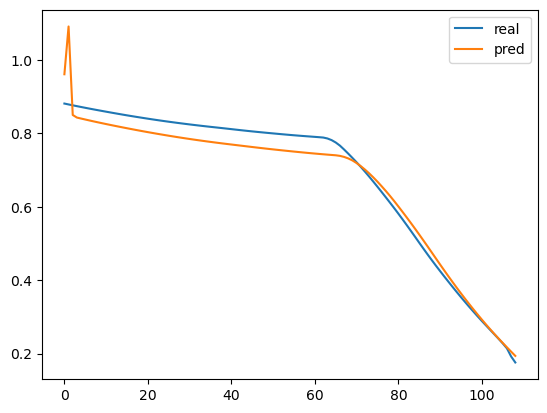

In [4]:
#nIN,nHS,nOUT,N1,N2,N3,lr,τ,lb,dt =params
params =  [13, 20, 8, 1e-06, 0.001, 1e-07, 0.0001, 1, 0.99, 10000.0]
params = params[:-2]
nIN,nHS,nOUT,N1,N2,N3,lr,τ, =params
#nIN,nHS,nOUT = 4,4,4
ηS = [N1,N2,N3]
X,Y = prepare_data(sig,n=nIN,m=nOUT)
i=0

rtlo = RTLO(nIN,nHS,nOUT,ηS,τ,lr)
for x,y in zip(X,Y):
    y_p = rtlo.PredSingle_V2(x,store=True)
    eP = rtlo.UpdateRLS(y_p,y)
    rtlo.fit_V2(x,y,store=True)
    i = i+1

print(rmse(rtlo.yR,rtlo.yP))
rtlo.PlotPred()

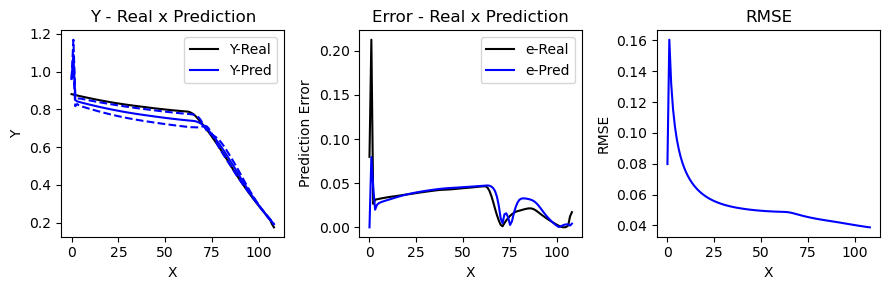

In [79]:
#nIN,nHS,nOUT,N1,N2,N3,lr,τ,lb,dt =params
params =  [13, 20, 8, 1e-06, 0.001, 1e-07, 0.0001, 1, 0.99, 10000.0]

nIN,nHS,nOUT,N1,N2,N3,lr,τ,_,_ = params

ηS = [N1,N2,N3]
X,Y = prepare_data(sig,n=nIN,m=nOUT)
xR,yR,yP = np.array([]),np.array([]),np.array([])

rtlo = RTLO(nIN,nHS,nOUT,ηS,τ,lr)
yL,yU = np.array([]),np.array([])
xR = np.array([])
erroR = np.array([])
erroP = np.array([])

for i in range(len(X)):
#for i in range(2):
    #print(i)
    y_r = Y[i]
    #print('ht:',rtlo.ht)
    y_p = rtlo.PredSingle(X[i],store=True)
    eP = rtlo.UpdateRLS(y_p,y_r)
    y_L, y_U = rtlo.PredInterval(X[i],eP,store=True)
    rtlo.fit(X[i],Y[i],store=True)

rtlo.PlotPredError()


In [46]:
a = np.array([-1,1,-1,1])
np.minimum(0,a)

array([-1,  0, -1,  0])

In [75]:
ySrs, nms = rtlo.ySeries(s=5)
plot_series(ySeries=ySrs,names=nms)